In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

   # DATA PREPARATION

## Data Import

In [2]:
# Import patient information to create a DataFrame
base_path = r'.\data'
dataset = os.path.join(base_path,'pacientes_sinteticos.csv')
df_dataset = pd.read_csv(dataset)

In [3]:
df_dataset.sample(5)

,Paciente,Num_Visitas,Num_Especialidades,Num_Diagnosticos,Pct_Hospitalizacion
49923,SYN_049924,1,2,0,0.0
99102,SYN_099103,1,1,0,0.0
8227,SYN_008228,1,0,1,0.0
55821,SYN_055822,1,0,0,0.0
90696,SYN_090697,3,1,0,0.0


## Dataset Validation

It is necessary to review variable data types and check for missing values.

In [4]:
# Variables included in the model
variables_gmm = [
    "Num_Visitas",
    "Pct_Hospitalizacion",
    "Num_Especialidades",
    "Num_Diagnosticos"
]

# Create a modeling-specific dataset
df_gmm = df_dataset[["Paciente"] + variables_gmm].copy()

# Review the dataset structure
print("Dimensiones:", df_gmm.shape)
print("\nTipos de datos:")
print(df_gmm.dtypes)

print("\nValores nulos:")
print(df_gmm[variables_gmm].isna().sum())

print("\nEstadísticos:")
print(df_gmm[variables_gmm].describe())

Dimensiones: (100000, 5)

Tipos de datos:
Paciente                   str
Num_Visitas              int64
Pct_Hospitalizacion    float64
Num_Especialidades       int64
Num_Diagnosticos         int64
dtype: object

Valores nulos:
Num_Visitas            0
Pct_Hospitalizacion    0
Num_Especialidades     0
Num_Diagnosticos       0
dtype: int64

Estadísticos:
         Num_Visitas  Pct_Hospitalizacion  Num_Especialidades  \
count  100000.000000        100000.000000       100000.000000   
mean        2.001820             0.068117            0.636600   
std         1.416466             0.212125            0.859132   
min         1.000000             0.000000            0.000000   
25%         1.000000             0.000000            0.000000   
50%         2.000000             0.000000            0.000000   
75%         3.000000             0.000000            1.000000   
max        19.000000             1.000000            7.000000   

       Num_Diagnosticos  
count     100000.000000  
mean   

## Variable Distribution Analysis

Para cada una de las variables se va a buscar asimetría, concentración de valores, colar largas, valores extremos y posibles concentraciones o grupos naturales.

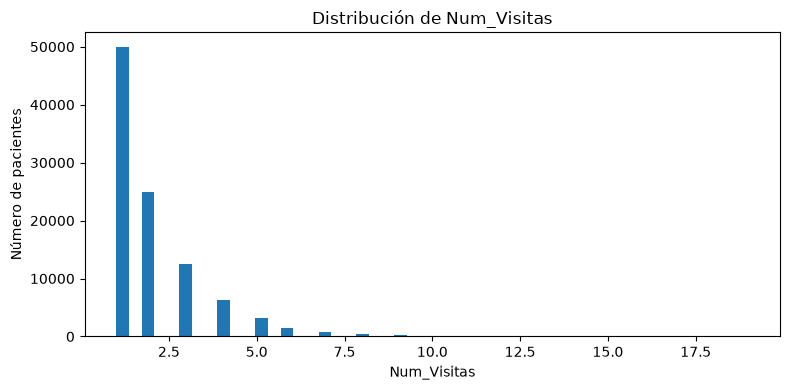

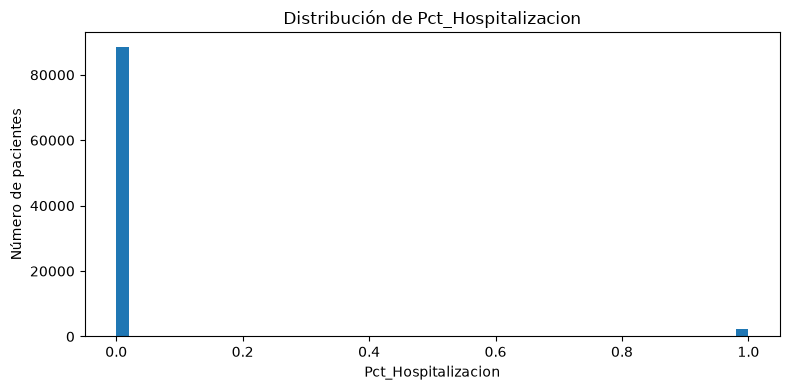

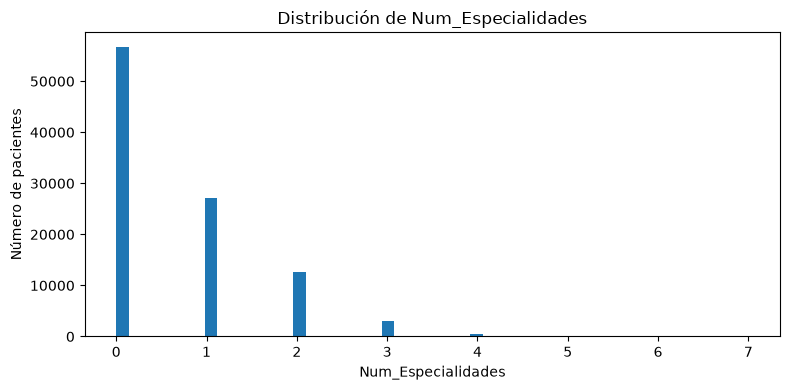

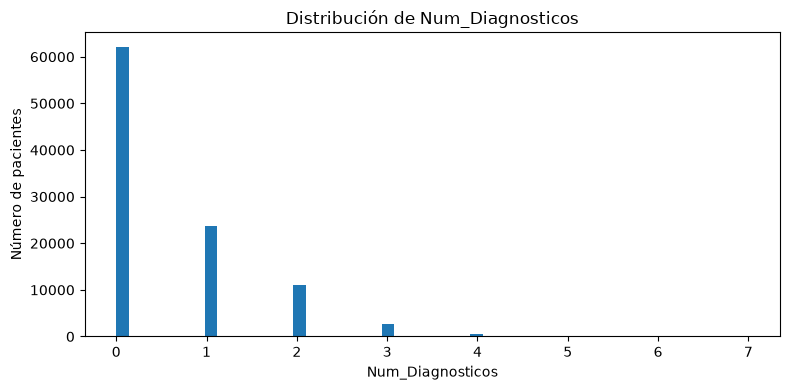

In [5]:
for variable in variables_gmm:

    plt.figure(figsize=(8, 4))

    plt.hist(
        df_gmm[variable],
        bins=50
    )

    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Número de pacientes")

    plt.tight_layout()
    plt.show()

In [6]:
# Variables included in the model
variables_gmm = [
    "Num_Visitas",
    "Pct_Hospitalizacion",
    "Num_Especialidades",
    "Num_Diagnosticos"
]

# Percentiles to evaluate
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]

# Create a percentile table
tabla_percentiles = (
    df_gmm[variables_gmm]
    .quantile(percentiles)
    .T
)

# Rename columns
tabla_percentiles.columns = [
    "P01", "P05", "P10", "P25", "P50",
    "P75", "P90", "P95", "P99", "P99_5", "P99_9"
]

# Additional statistics
tabla_distribucion = pd.DataFrame(index=variables_gmm)

tabla_distribucion["Media"] = df_gmm[variables_gmm].mean()
tabla_distribucion["Mediana"] = df_gmm[variables_gmm].median()
tabla_distribucion["Desv_Estandar"] = df_gmm[variables_gmm].std()
tabla_distribucion["Min"] = df_gmm[variables_gmm].min()
tabla_distribucion["Max"] = df_gmm[variables_gmm].max()
tabla_distribucion["Asimetria"] = df_gmm[variables_gmm].skew()
tabla_distribucion["Curtosis"] = df_gmm[variables_gmm].kurtosis()

# Zero count and percentage
tabla_distribucion["N_Ceros"] = (
    (df_gmm[variables_gmm] == 0).sum()
)

tabla_distribucion["Pct_Ceros"] = (
    (df_gmm[variables_gmm] == 0).mean() * 100
)

# Display statistics
print("===== ESTADÍSTICAS DE DISTRIBUCIÓN =====")
display(tabla_distribucion.round(4))

print("\n===== PERCENTILES =====")
display(tabla_percentiles.round(4))

===== ESTADÍSTICAS DE DISTRIBUCIÓN =====


,Media,Mediana,Desv_Estandar,Min,Max,Asimetria,Curtosis,N_Ceros,Pct_Ceros
Num_Visitas,2.0018,2.0,1.4165,1.0,19.0,2.1372,6.7361,0,0.000
Pct_Hospitalizacion,0.0681,0.0,0.2121,0.0,1.0,3.2371,9.5689,88554,88.554
Num_Especialidades,0.6366,0.0,0.8591,0.0,7.0,1.3131,1.3644,56742,56.742
Num_Diagnosticos,0.5594,0.0,0.8364,0.0,7.0,1.5248,2.0548,62136,62.136



===== PERCENTILES =====


,P01,P05,P10,P25,P50,P75,P90,P95,P99,P99_5,P99_9
Num_Visitas,1.0,1.0,1.0,1.0,2.0,3.0,4.0000,5.0000,7.0,8.0,11.0
Pct_Hospitalizacion,0.0,0.0,0.0,0.0,0.0,0.0,0.2496,0.6313,1.0,1.0,1.0
Num_Especialidades,0.0,0.0,0.0,0.0,0.0,1.0,2.0000,2.0000,3.0,4.0,4.0
Num_Diagnosticos,0.0,0.0,0.0,0.0,0.0,1.0,2.0000,2.0000,3.0,4.0,4.0


## Variable Transformation

In [7]:
# Create a modeling-specific copy of the dataset
df_gmm_model = df_gmm.copy()

# Positively skewed count variables
variables_log = [
    "Num_Visitas",
    "Num_Especialidades",
    "Num_Diagnosticos"
]

# Apply a log transformation
for variable in variables_log:
    df_gmm_model[variable] = np.log1p(
        df_gmm_model[variable]
    )

# Review the results
print("Estadísticas después de la transformación:")
display(
    df_gmm_model[variables_gmm]
    .describe()
    .round(4)
)

Estadísticas después de la transformación:


,Num_Visitas,Pct_Hospitalizacion,Num_Especialidades,Num_Diagnosticos
count,100000.0000,100000.0000,100000.0000,100000.0000
mean,1.0162,0.0681,0.3771,0.3307
std,0.3837,0.2121,0.4615,0.4506
min,0.6931,0.0000,0.0000,0.0000
25%,0.6931,0.0000,0.0000,0.0000
50%,1.0986,0.0000,0.0000,0.0000
75%,1.3863,0.0000,0.6931,0.6931
max,2.9957,1.0000,2.0794,2.0794


## Variable Standarization

In [8]:
# Model feature matrix
X = df_gmm_model[variables_gmm].copy()

# Create a feature scaler
scaler = StandardScaler()

# Standardize features
X_scaled = scaler.fit_transform(X)

# Convert the data back to a DataFrame for inspection
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=variables_gmm,
    index=df_gmm_model.index
)

print("Dimensiones de X_scaled:", X_scaled_df.shape)

print("\nMedia de las variables estandarizadas:")
print(X_scaled_df.mean().round(4))

print("\nDesviación estándar:")
print(X_scaled_df.std().round(4))

Dimensiones de X_scaled: (100000, 4)

Media de las variables estandarizadas:
Num_Visitas            0.0
Pct_Hospitalizacion    0.0
Num_Especialidades    -0.0
Num_Diagnosticos      -0.0
dtype: float64

Desviación estándar:
Num_Visitas            1.0
Pct_Hospitalizacion    1.0
Num_Especialidades     1.0
Num_Diagnosticos       1.0
dtype: float64


## Dimension Review

In [9]:
print("df_gmm:", df_gmm.shape)
print("df_gmm_model:", df_gmm_model.shape)
print("X:", X.shape)
print("X_scaled:", X_scaled.shape)

df_gmm: (100000, 5)
df_gmm_model: (100000, 5)
X: (100000, 4)
X_scaled: (100000, 4)


### Index Validation

In [10]:
indices_originales = set(df_gmm_model.index)
indices_modelo = set(X_scaled_df.index)

faltantes = indices_originales - indices_modelo

print("Registros faltantes:", len(faltantes))

if faltantes:
    print("\nRegistro(s) faltante(s):")
    display(
        df_gmm_model.loc[list(faltantes)]
    )

Registros faltantes: 0


# MODEL DEVELOPMENT

## Evaluation of different numbers of components

Three different criteria are used to evaluate the number of components:

- BIC (Bayesian Information Criterion): penalizes overly complex models. Lower values generally indicate a better fit.
- AIC (Akaike Information Criterion): also penalizes model complexity. Lower values are preferred.
- Silhouette Score: measures the degree of separation between clusters. Higher values indicate better-defined clusters.

In other words, different segmentation hypotheses are explored by varying the number of components.  

The "full" covariance_type setting was selected to allow each component to have its own covariance matrix. This enables the model to capture relationships among variables rather than assuming that all variables are independent.

In [11]:
# Number of components to evaluate
rangos_componentes = range(2, 9)

resultados_gmm = []

for k in rangos_componentes:

    print(f"Ajustando GMM con {k} componentes...")

    # Create the model
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=5
    )

    # Fit the model
    gmm.fit(X_scaled)

    # Asignar cluster
    labels = gmm.predict(X_scaled)

    # Metrics
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    resultados_gmm.append({
        "n_components": k,
        "BIC": bic,
        "AIC": aic,
        "Silhouette": silhouette
    })

# Create a results table
resultados_gmm = pd.DataFrame(resultados_gmm)

print("\n===== RESULTADOS GMM =====")

display(
    resultados_gmm.round(4)
)

Ajustando GMM con 2 componentes...
Ajustando GMM con 3 componentes...
Ajustando GMM con 4 componentes...
Ajustando GMM con 5 componentes...
Ajustando GMM con 6 componentes...
Ajustando GMM con 7 componentes...
Ajustando GMM con 8 componentes...

===== RESULTADOS GMM =====


,n_components,BIC,AIC,Silhouette
0,2,-1.015367e+05,-1.018126e+05,0.3968
1,3,-8.407154e+05,-8.411340e+05,0.3280
2,4,-1.279086e+06,-1.279647e+06,0.3503
3,5,-1.533626e+06,-1.534330e+06,0.3443
4,6,-1.748371e+06,-1.749218e+06,0.4357
5,7,-1.749855e+06,-1.750844e+06,0.4350
6,8,-1.844407e+06,-1.845539e+06,0.4404


The 8-component GMM was identified as the leading candidate, achieving the best overall performance across all evaluation metrics, including the lowest BIC and AIC values and the highest Silhouette Score.  

The 6-component model represents a more parsimonious and interpretable alternative, with cluster separation performance comparable to that of the 8-component solution.  

# MODEL ANALYSIS

## Cluster Size Comparison

In [12]:
modelos_gmm = {}

for k in [6, 8]:

    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=5
    )

    gmm.fit(X_scaled)

    labels = gmm.predict(X_scaled)
    probabilidades = gmm.predict_proba(X_scaled)

    # Tamaño de cada cluster
    conteo = pd.Series(labels).value_counts().sort_index()

    porcentaje = (
        conteo / len(labels) * 100
    )

    # Probabilidad promedio de pertenencia
    prob_media = probabilidades.max(axis=1)

    resumen = pd.DataFrame({
        "Cluster": conteo.index,
        "N_Pacientes": conteo.values,
        "Pct_Pacientes": porcentaje.values
    })

    print(f"\n===== GMM con {k} componentes =====")
    display(resumen.round(3))

    print(
        "Probabilidad máxima promedio:",
        round(prob_media.mean(), 4)
    )

    modelos_gmm[k] = gmm


===== GMM con 6 componentes =====


,Cluster,N_Pacientes,Pct_Pacientes
0,0,14637,14.637
1,1,22258,22.258
2,2,11446,11.446
3,3,15550,15.550
4,4,18229,18.229
5,5,17880,17.880


Probabilidad máxima promedio: 1.0

===== GMM con 8 componentes =====


,Cluster,N_Pacientes,Pct_Pacientes
0,0,3228,3.228
1,1,22258,22.258
2,2,17880,17.880
3,3,7012,7.012
4,4,12322,12.322
5,5,18229,18.229
6,6,14637,14.637
7,7,4434,4.434


Probabilidad máxima promedio: 0.9869


## Utilization profile K=6

In [13]:
# Provisionally selected model
gmm_6 = modelos_gmm[6]

# Retrueve the cluster assignment for each patient
labels_6 = gmm_6.predict(X_scaled)

# Create an analysis dataset with the original variables
df_perfiles_6 = df_gmm.copy()

# Add clusters labels
df_perfiles_6["Cluster"] = labels_6

# Reorder variables
columnas_perfil = [
    "Cluster",
    "Num_Visitas",
    "Pct_Hospitalizacion",
    "Num_Especialidades",
    "Num_Diagnosticos"
]

# Medians by cluster
perfil_mediana_6 = (
    df_perfiles_6[columnas_perfil]
    .groupby("Cluster")
    .median()
)

print("===== MEDIANAS POR CLUSTER =====")

display(
    perfil_mediana_6.round(4)
)

===== MEDIANAS POR CLUSTER =====


,Num_Visitas,Pct_Hospitalizacion,Num_Especialidades,Num_Diagnosticos
Cluster,,,,
0,2.0,0.0000,0.0,0.0
1,2.0,0.0000,1.0,0.0
2,2.0,0.5787,0.0,0.0
3,2.0,0.0000,1.0,1.0
4,1.0,0.0000,0.0,0.0
5,2.0,0.0000,0.0,1.0


### Profile distribution

In [14]:
estadisticas_perfil_6 = {}

for variable in variables_gmm:

    estadisticas_perfil_6[variable] = (
        df_perfiles_6
        .groupby("Cluster")[variable]
        .agg(
            Media="mean",
            P25=lambda x: x.quantile(0.25),
            Mediana="median",
            P75=lambda x: x.quantile(0.75),
            P90=lambda x: x.quantile(0.90)
        )
    )

# Display each variable
for variable, tabla in estadisticas_perfil_6.items():

    print(f"\n===== {variable} =====")

    display(
        tabla.round(4)
    )


===== Num_Visitas =====


,Media,P25,Mediana,P75,P90
Cluster,,,,,
0,2.8770,2.0,2.0,3.0,5.0
1,1.9841,1.0,2.0,2.0,4.0
2,2.1422,1.0,2.0,3.0,4.0
3,2.2335,1.0,2.0,3.0,4.0
4,1.0000,1.0,1.0,1.0,1.0
5,2.0374,1.0,2.0,3.0,4.0



===== Pct_Hospitalizacion =====


,Media,P25,Mediana,P75,P90
Cluster,,,,,
0,0.0000,0.0000,0.0000,0.000,0.0
1,0.0000,0.0000,0.0000,0.000,0.0
2,0.5951,0.3691,0.5787,0.838,1.0
3,0.0000,0.0000,0.0000,0.000,0.0
4,0.0000,0.0000,0.0000,0.000,0.0
5,0.0000,0.0000,0.0000,0.000,0.0



===== Num_Especialidades =====


,Media,P25,Mediana,P75,P90
Cluster,,,,,
0,0.0000,0.0,0.0,0.0,0.0
1,1.4269,1.0,1.0,2.0,2.0
2,0.7318,0.0,0.0,1.0,2.0
3,1.5127,1.0,1.0,2.0,2.0
4,0.0000,0.0,0.0,0.0,0.0
5,0.0000,0.0,0.0,0.0,0.0



===== Num_Diagnosticos =====


,Media,P25,Mediana,P75,P90
Cluster,,,,,
0,0.0000,0.0,0.0,0.0,0.0
1,0.0000,0.0,0.0,0.0,0.0
2,0.5771,0.0,0.0,1.0,2.0
3,1.5615,1.0,1.0,2.0,3.0
4,0.0000,0.0,0.0,0.0,0.0
5,1.4010,1.0,1.0,2.0,2.0


### Cluster membership probability analysis

In [15]:
probabilidades = gmm.predict_proba(X_scaled)

In [16]:
probabilidades

array([[1.96668136e-07, 9.99983362e-01, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 2.30484053e-11],
       [1.29577648e-16, 3.05687571e-09, 2.00807800e-09, ...,
        9.99909920e-01, 9.00744992e-05, 4.69329893e-17],
       [5.64409020e-09, 9.99984430e-01, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 2.40119820e-11],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 2.01971860e-06],
       [1.29577648e-16, 3.05687571e-09, 2.00807800e-09, ...,
        9.99909920e-01, 9.00744992e-05, 4.69329893e-17],
       [1.29577648e-16, 3.05687571e-09, 2.00807800e-09, ...,
        9.99909920e-01, 9.00744992e-05, 4.69329893e-17]],
      shape=(100000, 8))

### Assigment confidence

In [17]:
# Cluster membership probabilities for K=6
probabilidades_6 = gmm_6.predict_proba(X_scaled)

# Probability of the assigned cluster
prob_max_6 = probabilidades_6.max(axis=1)

# Confidence summary
resumen_confianza_6 = pd.Series(
    prob_max_6
).describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

print("===== CONFIANZA DE ASIGNACIÓN GMM K=6 =====")

display(
    resumen_confianza_6.round(4)
)

===== CONFIANZA DE ASIGNACIÓN GMM K=6 =====


count    100000.0000
mean          1.0000
std           0.0000
min           0.9987
10%           0.9999
25%           1.0000
50%           1.0000
75%           1.0000
90%           1.0000
95%           1.0000
99%           1.0000
max           1.0000
dtype: float64

In [18]:
# Percentage of átients by confidence level

niveles_confianza = pd.cut(
    prob_max_6,
    bins=[0, 0.50, 0.70, 0.90, 0.95, 1.00],
    labels=[
        "<50%",
        "50%-70%",
        "70%-90%",
        "90%-95%",
        ">95%"
    ],
    include_lowest=True
)

# Convert to a series to ensure compatibility across pandas version
niveles_confianza = pd.Series(niveles_confianza)

# Count patients by confidence level
tabla_confianza = (
    niveles_confianza
    .value_counts()
    .reindex(niveles_confianza.cat.categories, fill_value=0)
    .to_frame("N_Pacientes")
)

# Calculate percentages
tabla_confianza["Pct_Pacientes"] = (
    tabla_confianza["N_Pacientes"]
    / len(prob_max_6)
    * 100
)

print("===== DISTRIBUCIÓN DE CONFIANZA DE ASIGNACIÓN =====")

display(
    tabla_confianza.round(2)
)

===== DISTRIBUCIÓN DE CONFIANZA DE ASIGNACIÓN =====


,N_Pacientes,Pct_Pacientes
<50%,0,0.0
50%-70%,0,0.0
70%-90%,0,0.0
90%-95%,0,0.0
>95%,100000,100.0


## Utilization Profile K=8

In [19]:
# GMM model with 8 components
gmm_8 = modelos_gmm[8]

# Assign each patient to a cluster
labels_8 = gmm_8.predict(X_scaled)

# Create an analysis dataset using the original variables
df_perfiles_8 = df_gmm.copy()

# Add cluster labels
df_perfiles_8["Cluster"] = labels_8

# Profile variables
columnas_perfil = [
    "Cluster",
    "Num_Visitas",
    "Pct_Hospitalizacion",
    "Num_Especialidades",
    "Num_Diagnosticos"
]

# Medians
perfil_mediana_8 = (
    df_perfiles_8[columnas_perfil]
    .groupby("Cluster")
    .median()
)

print("===== MEDIANAS POR CLUSTER — GMM K=8 =====")

display(
    perfil_mediana_8.round(4)
)

===== MEDIANAS POR CLUSTER — GMM K=8 =====


,Num_Visitas,Pct_Hospitalizacion,Num_Especialidades,Num_Diagnosticos
Cluster,,,,
0,4.0,0.0000,2.0,2.0
1,2.0,0.0000,1.0,0.0
2,2.0,0.0000,0.0,1.0
3,2.0,0.5808,0.0,0.0
4,1.0,0.0000,1.0,1.0
5,1.0,0.0000,0.0,0.0
6,2.0,0.0000,0.0,0.0
7,2.0,0.5754,1.0,1.0


In [20]:
estadisticas_perfil_8 = {}

for variable in variables_gmm:

    estadisticas_perfil_8[variable] = (
        df_perfiles_8
        .groupby("Cluster")[variable]
        .agg(
            Media="mean",
            P25=lambda x: x.quantile(0.25),
            Mediana="median",
            P75=lambda x: x.quantile(0.75),
            P90=lambda x: x.quantile(0.90)
        )
    )

for variable, tabla in estadisticas_perfil_8.items():

    print(f"\n===== {variable} =====")

    display(
        tabla.round(4)
    )


===== Num_Visitas =====


,Media,P25,Mediana,P75,P90
Cluster,,,,,
0,4.6964,4.0,4.0,5.0,7.0
1,1.9841,1.0,2.0,2.0,4.0
2,2.0374,1.0,2.0,3.0,4.0
3,2.0254,1.0,2.0,3.0,4.0
4,1.5883,1.0,1.0,2.0,3.0
5,1.0000,1.0,1.0,1.0,1.0
6,2.8770,2.0,2.0,3.0,5.0
7,2.3270,1.0,2.0,3.0,4.7



===== Pct_Hospitalizacion =====


,Media,P25,Mediana,P75,P90
Cluster,,,,,
0,0.0000,0.0000,0.0000,0.0000,0.0
1,0.0000,0.0000,0.0000,0.0000,0.0
2,0.0000,0.0000,0.0000,0.0000,0.0
3,0.5966,0.3675,0.5808,0.8418,1.0
4,0.0000,0.0000,0.0000,0.0000,0.0
5,0.0000,0.0000,0.0000,0.0000,0.0
6,0.0000,0.0000,0.0000,0.0000,0.0
7,0.5927,0.3716,0.5754,0.8334,1.0



===== Num_Especialidades =====


,Media,P25,Mediana,P75,P90
Cluster,,,,,
0,1.7531,1.0,2.0,2.0,3.0
1,1.4269,1.0,1.0,2.0,2.0
2,0.0000,0.0,0.0,0.0,0.0
3,0.6763,0.0,0.0,1.0,2.0
4,1.4498,1.0,1.0,2.0,2.0
5,0.0000,0.0,0.0,0.0,0.0
6,0.0000,0.0,0.0,0.0,0.0
7,0.8196,0.0,1.0,1.0,2.0



===== Num_Diagnosticos =====


,Media,P25,Mediana,P75,P90
Cluster,,,,,
0,1.7354,1.0,2.0,2.0,3.0
1,0.0000,0.0,0.0,0.0,0.0
2,1.4010,1.0,1.0,2.0,2.0
3,0.0000,0.0,0.0,0.0,0.0
4,1.5160,1.0,1.0,2.0,2.0
5,0.0000,0.0,0.0,0.0,0.0
6,0.0000,0.0,0.0,0.0,0.0
7,1.4899,1.0,1.0,2.0,2.0


## Transition Matrix K=6 → K=8

In [21]:
# Add both clustering solutions to the same dataset
df_comparacion = df_gmm.copy()

df_comparacion["Cluster_K6"] = labels_6
df_comparacion["Cluster_K8"] = labels_8

# Contingency table
tabla_k7_k8 = pd.crosstab(
    df_comparacion["Cluster_K6"],
    df_comparacion["Cluster_K8"]
)

print("===== RELACIÓN ENTRE K=6 Y K=8 =====")

display(tabla_k7_k8)

===== RELACIÓN ENTRE K=6 Y K=8 =====


Cluster_K8,0,1,2,3,4,5,6,7
Cluster_K6,,,,,,,,
0,0,0,0,0,0,0,14637,0
1,0,22258,0,0,0,0,0,0
2,0,0,0,7012,0,0,0,4434
3,3228,0,0,0,12322,0,0,0
4,0,0,0,0,0,18229,0,0
5,0,0,17880,0,0,0,0,0


In [22]:
tabla_k6_k8_pct = pd.crosstab(
    df_comparacion["Cluster_K6"],
    df_comparacion["Cluster_K8"],
    normalize="index"
) * 100

print("===== DISTRIBUCIÓN PORCENTUAL =====")

display(
    tabla_k6_k8_pct.round(2)
)

===== DISTRIBUCIÓN PORCENTUAL =====


Cluster_K8,0,1,2,3,4,5,6,7
Cluster_K6,,,,,,,,
0,0.00,0.0,0.0,0.00,0.00,0.0,100.0,0.00
1,0.00,100.0,0.0,0.00,0.00,0.0,0.0,0.00
2,0.00,0.0,0.0,61.26,0.00,0.0,0.0,38.74
3,20.76,0.0,0.0,0.00,79.24,0.0,0.0,0.00
4,0.00,0.0,0.0,0.00,0.00,100.0,0.0,0.00
5,0.00,0.0,100.0,0.00,0.00,0.0,0.0,0.00


## Assignment confidence K=8

In [23]:
# Cluster membership probabilities for K=8
probabilidades_8 = gmm_8.predict_proba(X_scaled)

# Maximum membership probability
prob_max_8 = probabilidades_8.max(axis=1)

# Descriptive statistics
print("===== CONFIANZA DE ASIGNACIÓN GMM K=8 =====")

display(
    pd.Series(prob_max_8)
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .round(4)
)

===== CONFIANZA DE ASIGNACIÓN GMM K=8 =====


count    100000.0000
mean          0.9869
std           0.0641
min           0.5060
10%           0.9985
25%           0.9999
50%           1.0000
75%           1.0000
90%           1.0000
95%           1.0000
99%           1.0000
max           1.0000
dtype: float64

In [24]:
# Confidence level classification
niveles_confianza_8 = pd.cut(
    prob_max_8,
    bins=[0, 0.50, 0.70, 0.90, 0.95, 1.00],
    labels=[
        "<50%",
        "50%-70%",
        "70%-90%",
        "90%-95%",
        ">95%"
    ],
    include_lowest=True
)

niveles_confianza_8 = pd.Series(niveles_confianza_8)

tabla_confianza_8 = (
    niveles_confianza_8
    .value_counts()
    .reindex(
        niveles_confianza_8.cat.categories,
        fill_value=0
    )
    .to_frame("N_Pacientes")
)

tabla_confianza_8["Pct_Pacientes"] = (
    tabla_confianza_8["N_Pacientes"]
    / len(prob_max_8)
    * 100
)

print("===== DISTRIBUCIÓN DE CONFIANZA K=8 =====")

display(
    tabla_confianza_8.round(2)
)

===== DISTRIBUCIÓN DE CONFIANZA K=8 =====


,N_Pacientes,Pct_Pacientes
<50%,0,0.00
50%-70%,2148,2.15
70%-90%,1194,1.19
90%-95%,1308,1.31
>95%,95350,95.35


# PROFILE CHARACTERIZATION

## Master profile table

In [25]:
# Variables used in the model
variables_perfil = [
    "Num_Visitas",
    "Pct_Hospitalizacion",
    "Num_Especialidades",
    "Num_Diagnosticos"
]

# Number of patients by cluster
resumen_clusters = (
    df_perfiles_8
    .groupby("Cluster")
    .agg(
        N_Pacientes=("Paciente", "count"),
        Num_Visitas_Mediana=("Num_Visitas", "median"),
        Pct_Hospitalizacion_Mediana=("Pct_Hospitalizacion", "median"),
        Num_Especialidades_Mediana=("Num_Especialidades", "median"),
        Num_Diagnosticos_Mediana=("Num_Diagnosticos", "median")
    )
)

# ërcentage of patients
resumen_clusters["Pct_Pacientes"] = (
    resumen_clusters["N_Pacientes"]
    / len(df_perfiles_8)
    * 100
)

# Reorder columns
resumen_clusters = resumen_clusters[
    [
        "N_Pacientes",
        "Pct_Pacientes",
        "Num_Visitas_Mediana",
        "Pct_Hospitalizacion_Mediana",
        "Num_Especialidades_Mediana",
        "Num_Diagnosticos_Mediana"
    ]
]

print("===== PERFIL INTEGRAL GMM K=8 =====")

display(
    resumen_clusters.round(3)
)

===== PERFIL INTEGRAL GMM K=8 =====


,N_Pacientes,Pct_Pacientes,Num_Visitas_Mediana,Pct_Hospitalizacion_Mediana,Num_Especialidades_Mediana,Num_Diagnosticos_Mediana
Cluster,,,,,,
0,3228,3.228,4.0,0.000,2.0,2.0
1,22258,22.258,2.0,0.000,1.0,0.0
2,17880,17.880,2.0,0.000,0.0,1.0
3,7012,7.012,2.0,0.581,0.0,0.0
4,12322,12.322,1.0,0.000,1.0,1.0
5,18229,18.229,1.0,0.000,0.0,0.0
6,14637,14.637,2.0,0.000,0.0,0.0
7,4434,4.434,2.0,0.575,1.0,1.0


## Relative position

In [26]:
# Global medians
medianas_globales = df_perfiles_8[variables_perfil].median()

# Medians by cluster
medianas_cluster = (
    df_perfiles_8
    .groupby("Cluster")[variables_perfil]
    .median()
)

# Ratio to the global median
razon_vs_global = medianas_cluster / medianas_globales

print("===== MEDIANAS POR CLUSTER =====")

display(
    medianas_cluster.round(4)
)

print("\n===== RAZÓN MEDIANA CLUSTER / MEDIANA GLOBAL =====")

display(
    razon_vs_global.round(2)
)

===== MEDIANAS POR CLUSTER =====


,Num_Visitas,Pct_Hospitalizacion,Num_Especialidades,Num_Diagnosticos
Cluster,,,,
0,4.0,0.0000,2.0,2.0
1,2.0,0.0000,1.0,0.0
2,2.0,0.0000,0.0,1.0
3,2.0,0.5808,0.0,0.0
4,1.0,0.0000,1.0,1.0
5,1.0,0.0000,0.0,0.0
6,2.0,0.0000,0.0,0.0
7,2.0,0.5754,1.0,1.0



===== RAZÓN MEDIANA CLUSTER / MEDIANA GLOBAL =====


,Num_Visitas,Pct_Hospitalizacion,Num_Especialidades,Num_Diagnosticos
Cluster,,,,
0,2.0,NaN,inf,inf
1,1.0,NaN,inf,NaN
2,1.0,NaN,NaN,inf
3,1.0,inf,NaN,NaN
4,0.5,NaN,inf,inf
5,0.5,NaN,NaN,NaN
6,1.0,NaN,NaN,NaN
7,1.0,inf,inf,inf


## Structural cluster characterization

In [27]:
df_caracterizacion = df_perfiles_8.copy()

# Binary indicator
df_caracterizacion["Tiene_Hospitalizacion"] = (
    df_caracterizacion["Pct_Hospitalizacion"] > 0
).astype(int)

df_caracterizacion["Tiene_Especialidad"] = (
    df_caracterizacion["Num_Especialidades"] > 0
).astype(int)

df_caracterizacion["Tiene_Diagnostico"] = (
    df_caracterizacion["Num_Diagnosticos"] > 0
).astype(int)

# Utilization type
df_caracterizacion["Exclusivamente_Ambulatorio"] = (
    df_caracterizacion["Pct_Hospitalizacion"] == 0
).astype(int)

df_caracterizacion["Exclusivamente_Hospitalario"] = (
    df_caracterizacion["Pct_Hospitalizacion"] == 1
).astype(int)

df_caracterizacion["Utilizacion_Mixta"] = (
    (df_caracterizacion["Pct_Hospitalizacion"] > 0) &
    (df_caracterizacion["Pct_Hospitalizacion"] < 1)
).astype(int)


# Cluster summary

caracterizacion_clusters = (
    df_caracterizacion
    .groupby("Cluster")
    .agg(
        N_Pacientes=("Paciente", "count"),

        # Intensity
        Episodios_Mediana=("Num_Visitas", "median"),
        Episodios_P75=("Num_Visitas", lambda x: x.quantile(0.75)),
        Episodios_P90=("Num_Visitas", lambda x: x.quantile(0.90)),

        # Hospitalization
        Pct_Con_Hospitalizacion=("Tiene_Hospitalizacion", "mean"),
        Pct_Exclusivamente_Ambulatorio=(
            "Exclusivamente_Ambulatorio", "mean"
        ),
        Pct_Exclusivamente_Hospitalario=(
            "Exclusivamente_Hospitalario", "mean"
        ),
        Pct_Utilizacion_Mixta=(
            "Utilizacion_Mixta", "mean"
        ),

        # Medical specialties
        Pct_Con_Especialidad=("Tiene_Especialidad", "mean"),
        Especialidades_Mediana=("Num_Especialidades", "median"),

        # Diagnoses
        Pct_Con_Diagnostico=("Tiene_Diagnostico", "mean"),
        Diagnosticos_Mediana=("Num_Diagnosticos", "median")
    )
)

# Convert proportions to percentages
columnas_porcentaje = [
    "Pct_Con_Hospitalizacion",
    "Pct_Exclusivamente_Ambulatorio",
    "Pct_Exclusivamente_Hospitalario",
    "Pct_Utilizacion_Mixta",
    "Pct_Con_Especialidad",
    "Pct_Con_Diagnostico"
]

caracterizacion_clusters[columnas_porcentaje] *= 100

# Percentage of patients
caracterizacion_clusters["Pct_Pacientes"] = (
    caracterizacion_clusters["N_Pacientes"]
    / len(df_caracterizacion)
    * 100
)

# Reorder columns
caracterizacion_clusters = caracterizacion_clusters[
    [
        "N_Pacientes",
        "Pct_Pacientes",

        "Episodios_Mediana",
        "Episodios_P75",
        "Episodios_P90",

        "Pct_Con_Hospitalizacion",
        "Pct_Exclusivamente_Ambulatorio",
        "Pct_Exclusivamente_Hospitalario",
        "Pct_Utilizacion_Mixta",

        "Pct_Con_Especialidad",
        "Especialidades_Mediana",

        "Pct_Con_Diagnostico",
        "Diagnosticos_Mediana"
    ]
]

print("===== CARACTERIZACIÓN ESTRUCTURAL DE LOS PERFILES =====")

display(
    caracterizacion_clusters.round(2)
)

===== CARACTERIZACIÓN ESTRUCTURAL DE LOS PERFILES =====


,N_Pacientes,Pct_Pacientes,Episodios_Mediana,Episodios_P75,Episodios_P90,Pct_Con_Hospitalizacion,Pct_Exclusivamente_Ambulatorio,Pct_Exclusivamente_Hospitalario,Pct_Utilizacion_Mixta,Pct_Con_Especialidad,Especialidades_Mediana,Pct_Con_Diagnostico,Diagnosticos_Mediana
Cluster,,,,,,,,,,,,,
0,3228,3.23,4.0,5.0,7.0,0.0,100.0,0.00,0.00,100.00,2.0,100.0,2.0
1,22258,22.26,2.0,2.0,4.0,0.0,100.0,0.00,0.00,100.00,1.0,0.0,0.0
2,17880,17.88,2.0,3.0,4.0,0.0,100.0,0.00,0.00,0.00,0.0,100.0,1.0
3,7012,7.01,2.0,3.0,4.0,100.0,0.0,19.54,80.46,45.32,0.0,0.0,0.0
4,12322,12.32,1.0,2.0,3.0,0.0,100.0,0.00,0.00,100.00,1.0,100.0,1.0
5,18229,18.23,1.0,1.0,1.0,0.0,100.0,0.00,0.00,0.00,0.0,0.0,0.0
6,14637,14.64,2.0,3.0,5.0,0.0,100.0,0.00,0.00,0.00,0.0,0.0,0.0
7,4434,4.43,2.0,3.0,4.7,100.0,0.0,18.81,81.19,51.24,1.0,100.0,1.0


## Variable visualization

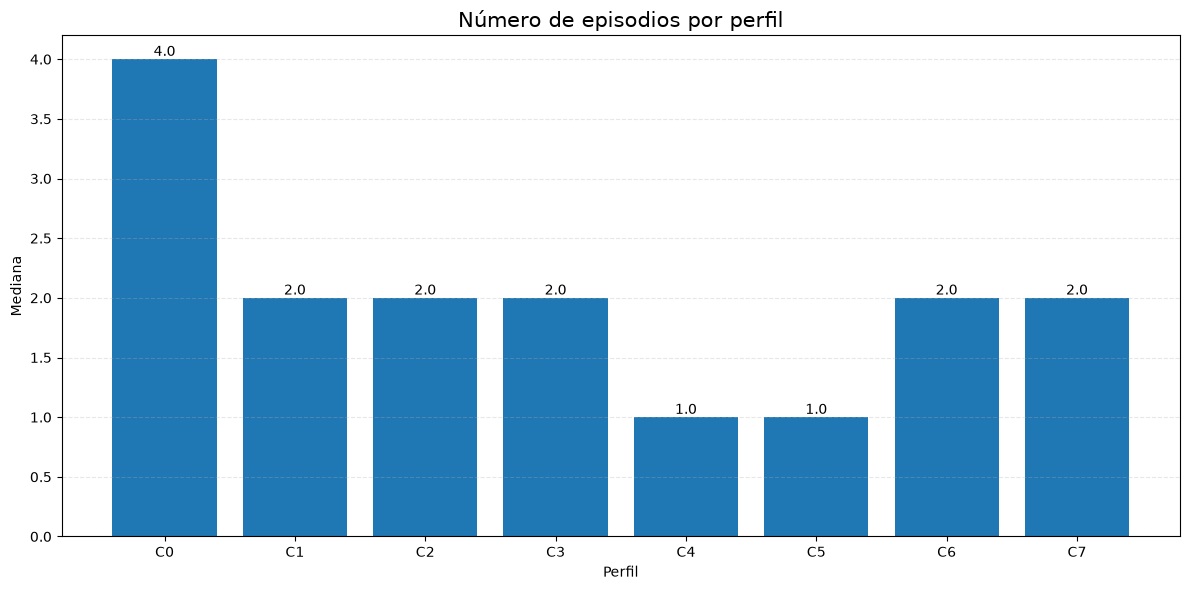

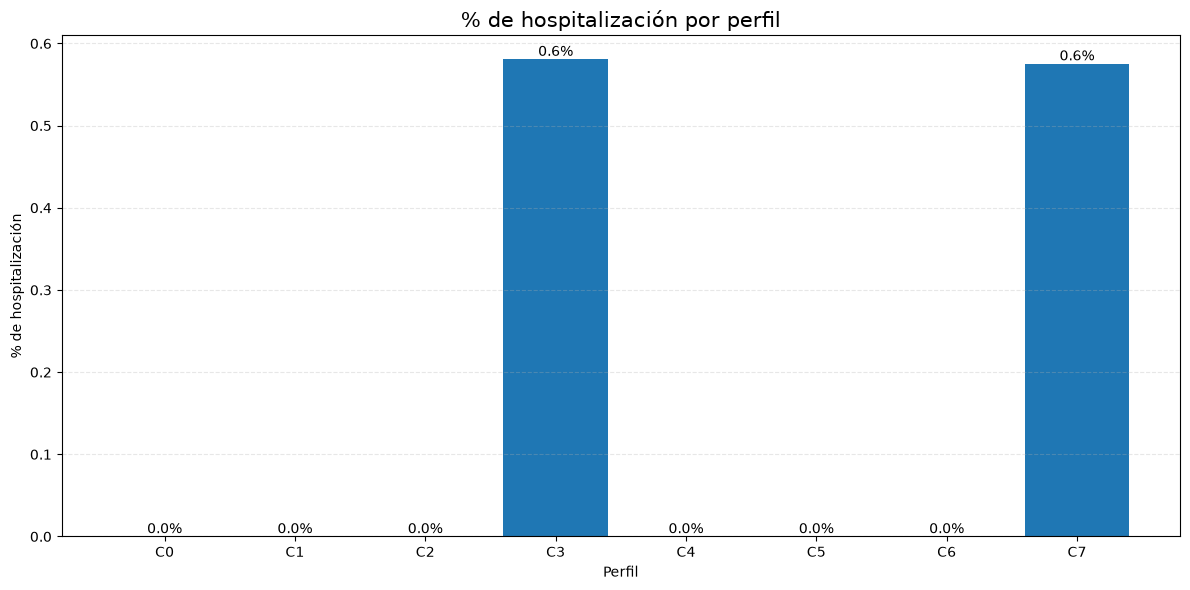

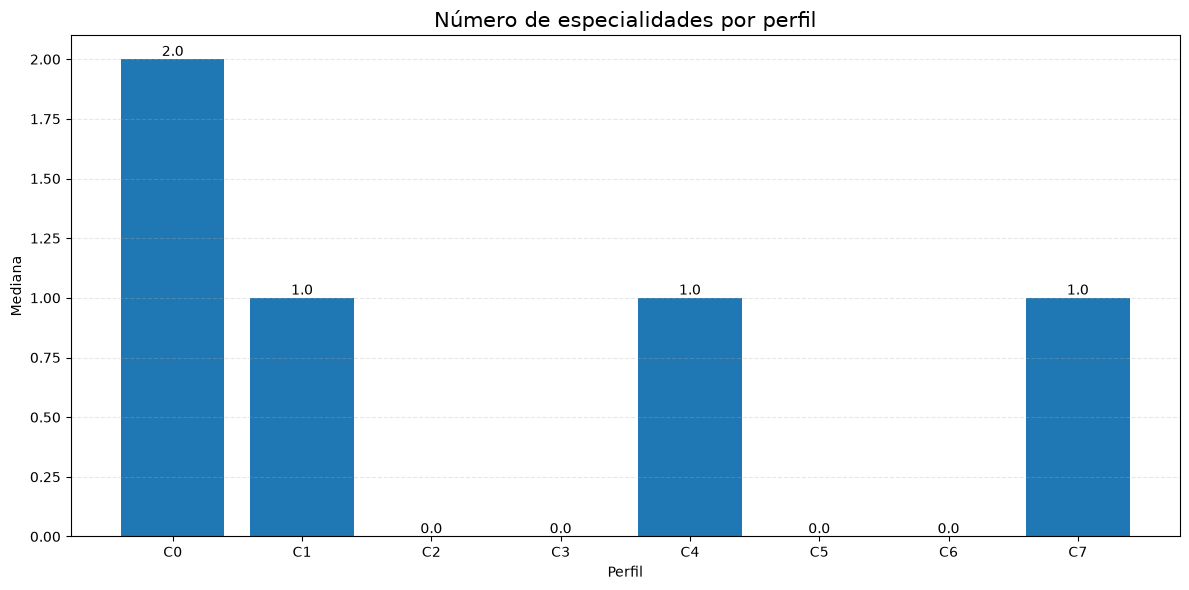

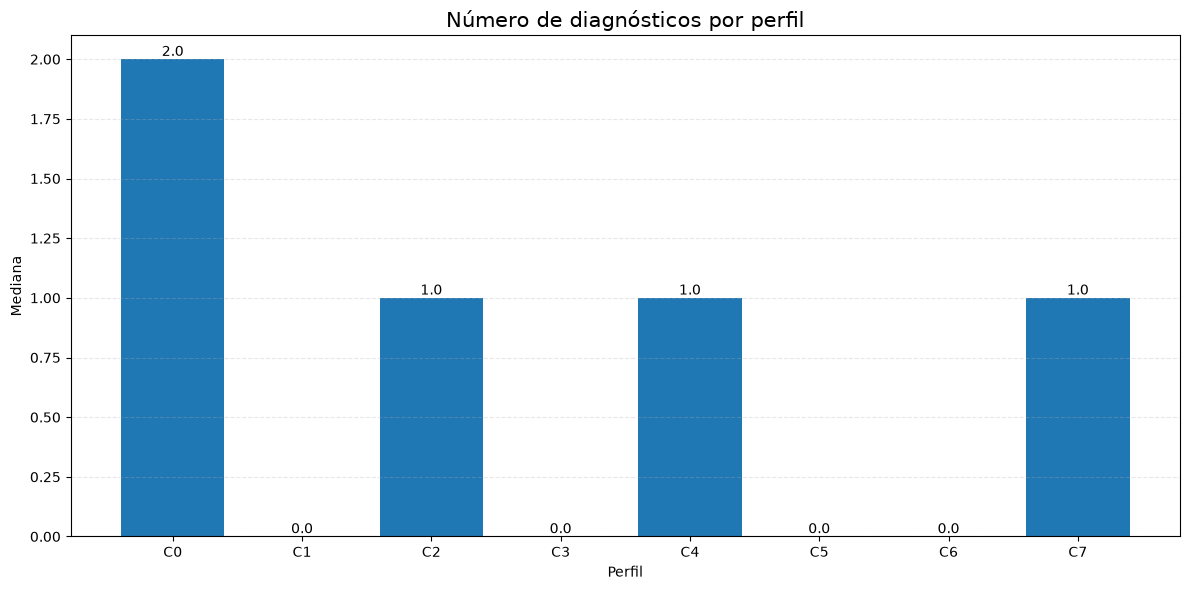

In [28]:
# Configuration
variables_analisis = [
    "Num_Visitas",
    "Pct_Hospitalizacion",
    "Num_Especialidades",
    "Num_Diagnosticos"
]

nombres_variables = {
    "Num_Visitas": "Número de episodios",
    "Pct_Hospitalizacion": "% de hospitalización",
    "Num_Especialidades": "Número de especialidades",
    "Num_Diagnosticos": "Número de diagnósticos"
}

# Data validation and preparation

# Create a copy to keep this section independent.
df_analisis = df_perfiles_8.copy()

# Verify that the required columns exist
columnas_requeridas = ["Cluster"] + variables_analisis

columnas_faltantes = [
    columna
    for columna in columnas_requeridas
    if columna not in df_analisis.columns
]

if columnas_faltantes:
    raise ValueError(
        f"Faltan las siguientes columnas en df_perfiles_8: "
        f"{columnas_faltantes}"
    )

# Retrieve cluster assignments directly from the DataFrame
orden_clusters = sorted(
    df_analisis["Cluster"].dropna().unique()
)

# Bar charts

for variable in variables_analisis:

    datos_grafica = (
        df_analisis
        .groupby("Cluster")[variable]
        .median()
        .reindex(orden_clusters)
    )

    plt.figure(figsize=(12, 6))

    barras = plt.bar(
        [f"C{cluster}" for cluster in datos_grafica.index],
        datos_grafica.values
    )

    # Value labels
    for barra, valor in zip(barras, datos_grafica.values):

        if variable == "Pct_Hospitalizacion":
            etiqueta = f"{valor:.1f}%"
        else:
            etiqueta = f"{valor:.1f}"

        plt.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height(),
            etiqueta,
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.title(
        f"{nombres_variables[variable]} por perfil",
        fontsize=15
    )

    plt.xlabel("Perfil")

    plt.ylabel(
        "% de hospitalización"
        if variable == "Pct_Hospitalizacion"
        else "Mediana"
    )

    plt.xticks(
        range(len(orden_clusters)),
        [f"C{cluster}" for cluster in orden_clusters]
    )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

# CONCLUSIONS

The comparison between the K=6 and K=8 solutions reveals a highly stable clustering structure. Four of the six clusters identified in the K=6 solution remain unchanged as the number of components increases, while the remaining two clusters are split into more specific segments.

The primary split occurs among outpatient patients with comprehensive clinical records, distinguishing between high- and low-intensity healthcare users. A second split is observed among hospitalized patients, separating profiles with different levels of clinical characterization.

These findings suggest that the K=6 solution captures the core healthcare utilization structure, whereas the K=8 solution provides a more granular segmentation without substantially altering the overall patterns identified.